# 💻 **Evidencia 1**

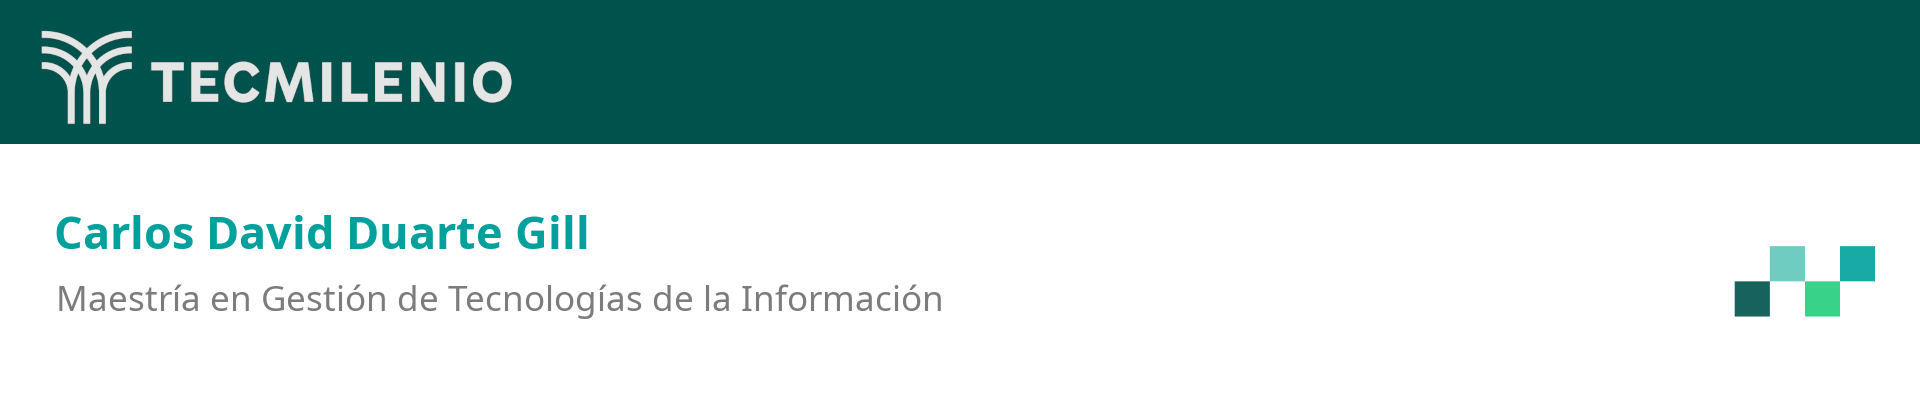

## **Aplicaciones avanzadas en ciencia de datos**

- Alumno: Carlos David Duarte Gill
- Matricula: 7089642
- Correo: AL07089642@tecmilenio.mx
- Profesor: Martín Antonio Santos Romero
- Fecha:  domingo 12 de abril de 2026

*Cursando la Maestría en Gestión de Tecnologías de la Información*

# 📘 Introducción a la Evidencia 1

La Evidencia 1 representa la suma de los esfuerzos dedicados al caso de NovaCredit Solutions tras haber explorado, limpiado y modelado los datos históricos de la cartera de clientes en las actividades previas. 
En esta primer evidencia se inicia con la transición de un análisis exploratorio fijo hacia la construcción de un Pipeline de Ciencia de Datos estructurado que nos permita integrar la predicción del riesgo de default en un flujo de trabajo gestionado bajo las bases de MLOps necesarias para que estos modelos generen valor continuo y automatizado en la toma de decisiones de la empresa.

## 🗽 Alcance de la Evidencia 1

En esta evidencia se logrará simular un entorno real de producción integrando el ciclo de vida del modelo predictivo. Para ello se incluirá:

- Estandarización de datos y tratamiento de desbalanceo nativo.

- Entrenamiento y optimización de hiperparámetros de modelos de ensamble como Random Forest para detectar morosidad temprana.

- Segmentación de clientes mediante K-Means y detección de anomalías con Isolation Forest para personalizar estrategias de cobranza y riesgo.

- Implementación de prácticas de rastreo de experimentos y control de versiones de modelos utilizando herramientas de la industria para garantizar auditoría y escalabilidad.

# 📖 Definición del problema analítico

## 📝 Contexto

El análisis histórico de NovaCredit Solutions ha revelado una tasa de morosidad alarmante que alcanza el 75.8% de la cartera de clientes lo que ocasiona que la empresa se enfrente a una crisis de rentabilidad. Dado este escenario, el problema de negocio radica en que la organización opera bajo un enfoque reactivo para la gestión del crédito, las políticas de captación y mantenimiento de líneas de crédito actuales no logran identificar oportunamente comportamientos morosos, permitiendo que perfiles de alto riesgo acaben con el capital de la empresa.

## 🏁 Objetivo analítico

El objetivo practico es diseñar, entrenar y desplegar un modelo predictivo de aprendizaje automático capaz de calcular la probabilidad individual de que un cliente incumpla con sus obligaciones crediticias, basándose en su perfil demográfico y comportamiento transaccional histórico. Este modelo actuará como un filtro automatizado para la toma de decisiones de la empresa.

La predicción se centrará en la variable objetivo **default_12m**.

## 🧭 Valor esperado de la solución

La implementación de este pipeline analítico y su despliegue operativo generará un impacto transformacional en tres frentes clave para NovaCredit:

- Reducción de pérdidas al predecir el riesgo con alta precisión la empresa podrá implementar políticas de congelamiento de líneas de crédito de forma automatizada, previniendo la fuga de capital.

- La rentabilidad comercial aumentará gracias a la segmentación de los clientes, el equipo de marketing podrá enfocar sus presupuestos de retención exclusivamente en los segmentos de bajo riesgo, maximizando el valor del ciclo de vida del cliente.

- La integración de MLOps permitirá mantener un modelo de decisiones en tiempo real, auditable y escalable para el futuro crecimiento de la empresa.

# 💻 Entorno Python para la Evidencia 1

Para garantizar la compatibilidad del código y su correcta ejecución, el proyecto fue desarrollado bajo un entorno virtual gestionado con Conda y    configurado con Python 3.10, en el entorno de desarrollo se incluyen herramientas tales como:

- Entorno de Desarrollo interactivo con *jupyter* para el desarrollo ágil y documentación eficiente.

- *pandas* para el procesamiento en memoria de la estructura tabular, respaldado por *matplotlib*, *seaborn* y *tabulate* para la generación de reportes ejecutivos visuales.

- Se integró el ecosistema *scikit-learn* junto con librerías de alto rendimiento para ensambles de gradiente como *xgboost*, *lightgbm* y *mlxtend*. 

- Adicionalmente, se preparó la infraestructura para experimentación con redes neuronales mediante *tensorflow* y *tensorflow_datasets*.

- Se instaló *mlflow* como componente clave para automatizar el registro de experimentos, métricas e hiperparámetros, facilitando el despliegue futuro del modelo ganador.

## 🏠 Selección del conjunto de datos

Para cumplir con los requisitos de la Evidencia 1 y asegurar todos los pasos requeridos durante su desarrollo, se utilizará el conjunto de datos original **novacredit_clientes
.csv** y se ejecutara una limpieza y transformación efectiva del mismo utilizando los mimos bloques de código desarrollados en la Actividad 2.

La única diferencia, es que estos códigos de carga, transformación y limpieza estarán dentro del pipeline, y, una vez transformado el dataset el código continuará con los entrenamientos correspondientes.

### 📒 Acerca del conjunto de datos

El conjunto de datos una vez limpio y preparado después de pasar por el pipeline será `novacredit_clientes_limpio.csv` y cuenta con 10,000 registros y 21 variables. Este nuevo archivo representa una versión optimizada del historial de clientes, diseñada específicamente para ser interpretada por algoritmos de aprendizaje automático.

Características principales:
- El dataset original paso por un proceso de limpieza y ya no existen valores nulos ni errores de encoding detectados anteriormente.
- Todas las variables numéricas han sido escaladas previamente mediante StandardScaler.
- Las variables categóricas de texto se han transformado en representaciones numéricas mediante técnicas de One-Hot Encoding y Ordinal Encoding.
- Se aplicaron técnicas de capping para reducir el efecto de los outliers en límites de crédito y saldos.

### 🔗 Carga el conjunto de datos en url pública

Para el desarrollo de la Evidencia 1 se cargo previamente el nuevo dataset en un [repositorio público en GitHub](https://raw.githubusercontent.com/RamRider89/aplicaciones-ciencia-datos/refs/heads/main/actividades/actividad-2/novacredit_clientes_limpio.csv)

# 💻 Desarrollo de la Evidencia 1

**A continuación:**

🧰 Se importan las librerías necesarias para el desarrollo de los modelos necesarios.

🔧 Se carga el dataset y se muestra una tabla descriptiva del dataset.

## 🧰 Carga de todas las librerías necesarias

In [1]:
# ------------------------------------------------------------------------------
# LIBRERIAS
# ------------------------------------------------------------------------------
try:
    # mlflow
    print("-" * 80)
    print("⚙️ Instalando mlflow...")
    !pip install mlflow --quiet

except Exception as e:
    print(f"❌ Error de instalación: {e}")

--------------------------------------------------------------------------------
⚙️ Instalando mlflow...


In [2]:
# ------------------------------------------------------------------------------
# LIBRERIAS
# ------------------------------------------------------------------------------
import sys
import os
# warnings
import warnings
import logging
warnings.filterwarnings('ignore')

try:
    # ------------------------------------------------------------------------------
    # liberias basicas
    # ------------------------------------------------------------------------------
    import pandas as pd
    import numpy as np
    # sklearn
    import sklearn

    # ------------------------------------------------------------------------------
    # Funciones sklearn, carga, limpieza, transformacion
    # ------------------------------------------------------------------------------
    from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

    # ------------
    # Segmentacion
    from sklearn.decomposition import PCA
    from sklearn.cluster import KMeans
    from sklearn.ensemble import IsolationForest

    # ------------------------------------------------------------------------------
    #  entrenamiento
    # ------------------------------------------------------------------------------
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import classification_report, roc_auc_score, roc_curve
    from sklearn.metrics import accuracy_score, precision_score, recall_score
    import tensorflow as tf
    import mlflow
    import mlflow.sklearn

    # ------------------------------------------------------------------------------
    # visualizacion
    # ------------------------------------------------------------------------------
    import matplotlib.pyplot as plt
    import seaborn as sns
    from tabulate import tabulate
    import plotly
    import plotly.express as px


    # ------------------------------------------------------------------------------
    print("-" * 80)
    print("⚙️ Cargando librerías core...")
    print(f"Python: {sys.version.split()[0]}")
    print(f"Pandas version: {pd.__version__}")
    print(f"NumPy version: {np.__version__}")
    print(f"scikit-learn version: {sklearn.__version__}")

    print("-" * 80)
    print("⚙️ Cargando librerías de machine learning...")
    print(f"Tensorflow - version: {tf.__version__}")
    print(f"MLFlow - version: {mlflow.__version__}")

    print("-" * 80)
    print("⚙️ Cargando librerías de visualización...")
    print(f"Matplotlib - version: {plt.matplotlib.__version__}")
    print(f"Seaborn version: {sns.__version__}")
    print(f"Plotly version: {plotly.__version__}")
    print("-" * 80)
    print("🚀 ¡Entorno preparado!")
    print("-" * 80)

except Exception as e:
    print(f"❌ Error de entorno, favor de instalar las dependencias necesarias: {e}")

warnings.filterwarnings('ignore')

I0000 00:00:1776204898.415962   90469 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776204898.492410   90469 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776204900.057472   90469 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


--------------------------------------------------------------------------------
⚙️ Cargando librerías core...
Python: 3.10.20
Pandas version: 2.3.3
NumPy version: 2.2.6
scikit-learn version: 1.7.2
--------------------------------------------------------------------------------
⚙️ Cargando librerías de machine learning...
Tensorflow - version: 2.21.0
MLFlow - version: 3.11.1
--------------------------------------------------------------------------------
⚙️ Cargando librerías de visualización...
Matplotlib - version: 3.10.8
Seaborn version: 0.13.2
Plotly version: 6.7.0
--------------------------------------------------------------------------------
🚀 ¡Entorno preparado!
--------------------------------------------------------------------------------


## 🗂 Variables de entorno

In [3]:
# ------------------------------------------------------------------------------
# VARIABLES DE ENTORNO
# ------------------------------------------------------------------------------
# colores tecmilenio
_color_tecmi_light="#26d07c"
_color_primary="#007bff"
_color_gray="#6c757d"
_color_white="#ffffff"
_color_danger="#ff0000"
_color_success="#28a745"
_color_info="#17a2b8"
_color_warning="#ffc107"

# Muted
_Gold_ = '#f0c571'
_Teal_ = '#59a89c'
_Blue_ = '#0b81a2'
_Red_ = '#e25759'
_Dark_Red_ = '#9d2c00'
_Purple_ = '#7E4794'
_Green_ = '#36b700'
_Gray_ = '#c8c8c8'

# paletas
_paleta_muted_ = [_Gold_, _Teal_, _Blue_, _Red_, _Dark_Red_, _Purple_, _Green_, _Gray_]
_paleta3_ = [_color_tecmi_light, _color_info, _color_warning]
# configuración de estilo visual
sns.set_theme(style="whitegrid")

### 🗂 Funciones auxiliares

In [4]:
# --------------------------------------------------------------------------
# 🤖 display mensaje
# --------------------------------------------------------------------------
def display_mensaje(msj):
    print("\n" + "="*80)
    print("\033[1m --- " + msj + " --- \033[0m")
    print("="*80)

In [5]:
# ------------------------------------------------------------------------------
# 🤖 diccionario builder
# ------------------------------------------------------------------------------

def dictionary_builder(columnas_categoricas, msj):

    _dict_unique_values_ = {}

    # recorremos las columnas categoricas para obtener sus valores
    display_mensaje(msj)
    # recorreos las columnas categoricas
    for col in columnas_categoricas.columns:
        # obtenemos los vals unicos
        unique_values = columnas_categoricas[col].unique()
        # asignamos los valores unicos al dict
        _dict_unique_values_[col] = columnas_categoricas[col].unique()


    # para mostrar el resultado del diccionario en pantalla
    # convertimos el diccionario a un conjunto de listas
    data = [[key] + list(value) for key, value in _dict_unique_values_.items()]

    # definimos los titulos de la tabla
    headers = ["Columna"] + [f"Valor único {i+1}" for i in range(len(max(_dict_unique_values_.values(), key=len)))]
    # imprimiendo
    print(tabulate(data, headers=headers, tablefmt="grid"))

    return _dict_unique_values_;

# 🤖 Construcción del pipeline de datos

A continuación se desarrollará un pipeline automatizado donde se encapsulen todas las transformaciones al dataset lo que garantizará que cualquier dato nuevo que entre al sistema sea tratado exactamente igual que los datos de entrenamiento.

## 💾 Funciones de carga y limpieza

En el primer bloque del pipeline se cargarán los datos desde la fuente original para corregir errores de codificación de texto.

In [6]:
# ------------------------------------------------------------------------------
# Pipeline
# Funciones de carga y limpieza
# ------------------------------------------------------------------------------

# !libs necesarias de sklearn:
# train_test_split, Pipeline, ColumnTransformer, SimpleImputer, StandardScaler, OneHotEncoder

# URL pública del dataset
_URL_PUBLICA_ = 'https://raw.githubusercontent.com/RamRider89/aplicaciones-ciencia-datos/refs/heads/main/actividades/actividad-1/novacredit_clientes.csv'
_URL_LOCAL_ = "./novacredit_clientes.csv"
_ARCHIVO_ORIGINAL_ = _URL_LOCAL_

# ------------------------------------------------------------------------------
# carga y limpieza inicial
# ------------------------------------------------------------------------------
def cargar_y_limpiar_datos(filepath):
    """
    Carga el dataset crudo y tratamiento de anomalías textuales en variables categoricas.
    El objetivo es corregir los errores de codificacion
    """
    print(f"Cargando datos desde: {filepath}...")
    df = pd.read_csv(filepath)
    
    # limpieza de caracteres extraños (ej. problemas de UTF-8)
    cols_texto = df.select_dtypes(include='object').columns
    reemplazos = {
        'Ã¡': 'á', 
        'Ã©': 'é', 
        'Ã­': 'í'
    }
    
    for col in cols_texto:
        df[col] = df[col].replace(reemplazos, regex=True)
        
    print(f"Datos cargados exitosamente con dimensiones: {df.shape}")
    return df

# ------------------------------------------------------------------------------
# integracion del archivo original
df_raw = cargar_y_limpiar_datos(_ARCHIVO_ORIGINAL_)

display_mensaje("💾 Recodificación finalizada")
df_nova_limpio = df_raw.copy()
df_nova_limpio.head()

Cargando datos desde: ./novacredit_clientes.csv...
Datos cargados exitosamente con dimensiones: (10000, 16)

 --- 💾 Recodificación finalizada --- 


,edad,ingreso_mensual,antiguedad_cliente_meses,segmento_cliente,region,canal_adquisicion,limite_credito,saldo_promedio,porcentaje_utilizacion,num_transacciones_mes,pagos_atrasados_12m,reclamos_12m,tipo_producto,tipo_contrato,metodo_pago,default_12m
0,45,NaN,1,Básico,Centro,Web,36554.88,13130.88,0.36,20,3,0,Tarjeta,Anual,Efectivo,1
1,38,11122.22,102,Premium,Norte,Sucursal,44606.35,11564.16,0.26,15,0,0,Tarjeta,Mensual,Transferencia,0
2,47,9335.42,38,Plus,Centro,Referido,24092.66,3835.81,0.16,16,1,1,Tarjeta,Mensual,Débito automático,1
3,58,14274.80,48,Básico,Sur,App,39951.95,2512.86,0.06,22,0,1,Tarjeta,Mensual,Efectivo,0
4,37,27400.24,28,Premium,Centro,Referido,108625.12,12242.81,0.11,23,2,1,Tarjeta,Anual,Efectivo,1


### 🗂 Análisis de columnas por tipo

Definimos los tipos de columnas para facilitar los siguientes procesos

In [7]:
# grupos de columnas
_COLUMNAS_NUMERICAS_ = ['edad', 'ingreso_mensual', 'antiguedad_cliente_meses', 'limite_credito', 
                  'saldo_promedio', 'porcentaje_utilizacion', 'num_transacciones_mes', 
                  'pagos_atrasados_12m', 'reclamos_12m']
_COLUMNAS_CATEGORICAS_ = ['region', 'canal_adquisicion', 'tipo_producto', 'tipo_contrato', 'metodo_pago']
_COLUMNAS_ORDINALES_ = ['segmento_cliente']

In [8]:
# ------------------------------------------------------------------------------
# valores unicos en cols categóricas
# ------------------------------------------------------------------------------
# en base a nuestras columnas categoricas: _Sex_, _Smoker_, _Region_
columnas_categoricas = df_raw[_COLUMNAS_CATEGORICAS_]
columnas_ordinales = df_raw[_COLUMNAS_ORDINALES_]

# definimos el diccionario de valores unicos
_DICT_CAT_ = dictionary_builder(columnas_categoricas, "Variables categóricas y valores únicos")
_DICT_ORDINAL_ = dictionary_builder(columnas_ordinales, "Variables ordinales y valores únicos")



 --- Variables categóricas y valores únicos --- 
+-------------------+-----------------+-----------------+-------------------+-----------------+
| Columna           | Valor único 1   | Valor único 2   | Valor único 3     | Valor único 4   |
+===================+=================+=================+===================+=================+
| region            | Centro          | Norte           | Sur               |                 |
+-------------------+-----------------+-----------------+-------------------+-----------------+
| canal_adquisicion | Web             | Sucursal        | Referido          | App             |
+-------------------+-----------------+-----------------+-------------------+-----------------+
| tipo_producto     | Tarjeta         | Préstamo        | Línea de crédito  |                 |
+-------------------+-----------------+-----------------+-------------------+-----------------+
| tipo_contrato     | Anual           | Mensual         |                   |         

## ♨️ Construcción del pipeline de transformación

En este bloque se realiza la preparación de datos, escalamiento de variables y codificación de datos.

In [9]:

# ------------------------------------------------------------------------------
# Pipeline de Transformación Final
# ------------------------------------------------------------------------------

# separando características y variable objetivo
X = df_nova_limpio.drop(columns=['default_12m', 'id_cliente'], errors='ignore') # caracteristicas
y = df_nova_limpio['default_12m'] # objetivo en y

# grupos de columnas
cols_numericas = _COLUMNAS_NUMERICAS_
cols_categoricas = _COLUMNAS_CATEGORICAS_
cols_ordinales = _COLUMNAS_ORDINALES_

print(f"Variables numéricas ({len(cols_numericas)}): {cols_numericas}")
print(f"Variables categóricas ({len(cols_categoricas)}): {cols_categoricas}")
print(f"Variables ordinales ({len(cols_ordinales)}): {cols_ordinales}\n")



# transformaciones para cada grupo
# ------------------------------------------------------------------------------

# Pipeline para transformacion de datos numéricas
# - relleno de valores nulos con la mediana
# - estandarización z-score
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


# ------------------------------------------------------------------------------
# Pipeline para transformacion de datos categóricas
# - relleno de valores nulos con la moda
# - One-Hot Encoding para las categorias
nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])



# ------------------------------------------------------------------------------
# Pipeline para transformacion de datos categóricas
# - relleno de valores nulos con la moda
# - One-Hot Encoding para las categorias
# transformacion ordinal en orden de categoria
orden_segmentos = [['Básico', 'Plus', 'Premium']]
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=orden_segmentos))
])


# ------------------------------------------------------------------------------
# procesamiento final
# grupo de transformaciones en un ColumnTransformer
preprocesador = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, cols_numericas),
        ('nom', nominal_transformer, cols_categoricas),
        ('ord', ordinal_transformer, cols_ordinales)
    ]
)


display_mensaje("🔗 Pipeline de preprocesamiento construido exitosamente.")

Variables numéricas (9): ['edad', 'ingreso_mensual', 'antiguedad_cliente_meses', 'limite_credito', 'saldo_promedio', 'porcentaje_utilizacion', 'num_transacciones_mes', 'pagos_atrasados_12m', 'reclamos_12m']
Variables categóricas (5): ['region', 'canal_adquisicion', 'tipo_producto', 'tipo_contrato', 'metodo_pago']
Variables ordinales (1): ['segmento_cliente']


 --- 🔗 Pipeline de preprocesamiento construido exitosamente. --- 


## 🚄 Ejecución y preparación final

En este bloque se dividen los datos en entrenamiento y prueba antes de aplicar las transformaciones matemáticas.

In [10]:
# ------------------------------------------------------------------------------
# 🚄 Ejecución y preparación final
# ------------------------------------------------------------------------------


# ------------------------------------------------------------------------------
# preprocesamiento en todo el conjunto de características
X_preprocesado = preprocesador.fit_transform(X)


# ------------------------------------------------------------------------------
# división estratificada 80/20 para entrenamiento y pruebas
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

display_mensaje("🤖 Aplicando transformaciones...")

# ------------------------------------------------------------------------------
# transformando con fit_transform para medias y desviaciones
# Esta variable se utilizara en los siguientes modelo random forest para entrenamiento
X_train_prep = preprocesador.fit_transform(X_train)

# transformando solo con transform en test para usar las medias aprendidas en train
# Esta variable se utilizará en random forest para evaluacion
X_test_prep = preprocesador.transform(X_test)

# aplicando los nombres de columnas originales + codificacion
nombres_nominales = preprocesador.named_transformers_['nom'].named_steps['onehot'].get_feature_names_out(cols_categoricas)
nombres_columnas_finales = cols_numericas + list(nombres_nominales) + cols_ordinales

# nuevo a dataframe de prueba y entrenamiento
df_train_prep = pd.DataFrame(X_train_prep, columns=nombres_columnas_finales)
df_test_prep = pd.DataFrame(X_test_prep, columns=nombres_columnas_finales)

# ------------------------------------------------------------------------------
print(f"Shape de X_train preparado: {df_train_prep.shape}")
print(f"Shape de X_test preparado:  {df_test_prep.shape}")
display_mensaje("🚀 Datos listos para ser procesados por el modelo predictivo")
display(df_train_prep.head(3))


 --- 🤖 Aplicando transformaciones... --- 
Shape de X_train preparado: (8000, 20)
Shape de X_test preparado:  (2000, 20)

 --- 🚀 Datos listos para ser procesados por el modelo predictivo --- 


,edad,ingreso_mensual,antiguedad_cliente_meses,limite_credito,saldo_promedio,porcentaje_utilizacion,num_transacciones_mes,pagos_atrasados_12m,reclamos_12m,region_Norte,region_Sur,canal_adquisicion_Referido,canal_adquisicion_Sucursal,canal_adquisicion_Web,tipo_producto_Préstamo,tipo_producto_Tarjeta,tipo_contrato_Mensual,metodo_pago_Efectivo,metodo_pago_Transferencia,segmento_cliente
0,0.200216,-0.750070,-0.870233,-0.547446,-0.480125,-0.297988,-0.700420,0.71706,-0.488198,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1,1.406599,-0.902873,-0.826489,-0.701288,-0.029142,1.722965,-0.468570,-0.18675,0.311963,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
2,2.095961,4.316548,-0.782744,4.077638,2.297354,-0.171678,0.690682,-0.18675,0.311963,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0


### Valor generado

Cada vez que se capten nuevos clientes al flujo de datos, simplemente se pasaran los datos crudos por la función preprocesador.transform(nuevo_cliente) y el código hará todo de forma automática.

### 💾 Guardando el nuevo dataset

In [11]:
display_mensaje("💾 Guardando el nuevo dataset")

# ------------------------------------------------------------------------------
# Dataset final
df_final_preparado = pd.DataFrame(X_preprocesado, columns=nombres_columnas_finales)
df_final_preparado['default_12m'] = y.values
df_final_preparado.to_csv("novacredit_clientes_limpio.csv", index=False)


 --- 💾 Guardando el nuevo dataset --- 


# 🧮 Modelado supervisado y comparación analítica

En este bloque se comparará el paradigma de modelos supervisados contra el aprendizaje profundo para justificar la decisión final ante el negocio.

## 🪶 Justificación de los modelos seleccionados

Para diseñar el modelo de predicción de la variable `default_12m`, se han seleccionado dos arquitecturas distintas para enseguida realizar una evaluación comparativa de ambos modelos.

### 🌳 Random Forest

El primer modelo será un Random Forest aprovechando que los datos de NovaCredit obtenidos desde la fuente de datos original son tabulares y estáticos. Debemos recordar que los arboles de decisión trabajan muy bien con este tipo de datos además de que manejan de manera optima las relaciones no lineales, no requieren arquitecturas complejas y permiten ajustar diferentes hiperparametros que ayudarían a lidiar con el 75.8% de morosidad sin necesitad de técnicas más complejas.

Un punto adicional para este tipo de modelo es su excelente **interpretabilidad** lo cual permite extraer la importancia de las variables apoyando a cumplir con las regulaciones y auditoría internas de la empresa.

### 🧠 Red Neuronal Simple

Se diseñara un modelo avanzado incorporando una capa oculta y una capa de salida utilizando `TensorFlow` / `Keras`. Debemos recordar que las redes neuronales son ideales para  descubrir patrones en datos no estructurados como imágenes, pero en datos tabulares es común que sufran de sobreajuste.

Su propósito será el de servir como modelo de prueba para evaluar si el `Deep Learning` logra un aumento de rentabilidad lo suficientemente importante como para justificar la pérdida de explicabilidad que ofrecen los arboles de decisión.

## 📱 Implementación y entrenamiento

Bloque para entrenar los modelos utilizando los datos preparados.

In [12]:
# ------------------------------------------------------------------------------
# 📱 Implementación y entrenamiento
# ------------------------------------------------------------------------------

# !libs necesarias de sklearn: RandomForestClassifier, classification_report, roc_auc_score, roc_curve
# !libs necesaria tensorflow & matplotlib

display_mensaje("🤖 Iniciando entrenamiento de los modelos")

# ------------------------------------------------------------------------------
# Modelo 1 - Random Forest
# ------------------------------------------------------------------------------
print("🌳 Entrenando Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10, 
    class_weight='balanced', # ajuste para manejar el desbalance de default
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_prep, y_train)

# ------------------------------------------------------------------------------
# predicciones del arbol
y_pred_rf = rf_model.predict(X_test_prep)
y_proba_rf = rf_model.predict_proba(X_test_prep)[:, 1]


# ------------------------------------------------------------------------------
# Modelo 2 - Red Neuronal Simple
# ------------------------------------------------------------------------------
print("🧠 Entrenando Red Neuronal Simple...")

# calculando pesos de clase manualmente para la Red Neuronal
neg, pos = np.bincount(y_train)
total = neg + pos
peso_0 = (1 / neg) * (total / 2.0) # Mayor peso a la clase minoritaria (Buen Cliente)
peso_1 = (1 / pos) * (total / 2.0) # Menor peso a la clase mayoritaria (Default)
pesos_clase = {0: peso_0, 1: peso_1}

# arquitectura - 1 capa oculta densa | 1 capa de salida
nn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(X_train_prep.shape[1],)),
    tf.keras.layers.Dropout(0.2), # evita el sobreajuste
    tf.keras.layers.Dense(1, activation='sigmoid') # salida binaria de prob
])

# ------------------------------------------------------------------------------
# compilando el modelo
nn_model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=[tf.keras.metrics.AUC(name='auc')]
)

# ------------------------------------------------------------------------------
# entrenando el modelo
history = nn_model.fit(
    X_train_prep, y_train, 
    epochs=20, 
    batch_size=32, 
    validation_split=0.2, 
    class_weight=pesos_clase, 
    verbose=0 # oculta texto largo en iteraciones
)

# ------------------------------------------------------------------------------
# predicciones red neuronal
y_proba_nn = nn_model.predict(X_test_prep, verbose=0).ravel()
y_pred_nn = (y_proba_nn > 0.5).astype(int)

display_mensaje("🤖 Entrenamiento completado para ambos modelos")


 --- 🤖 Iniciando entrenamiento de los modelos --- 
🌳 Entrenando Random Forest...
🧠 Entrenando Red Neuronal Simple...


E0000 00:00:1776204904.247590   90469 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776204904.247970   90643 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776204904.267563   90469 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



 --- 🤖 Entrenamiento completado para ambos modelos --- 


## ♊ Evaluación comparativa de desempeño

En el siguiente bloque se generan las métricas y la gráfica ROC para comparar matemáticamente qué arquitectura capturó mejor el riesgo.

In [13]:
# ------------------------------------------------------------------------------
# ♊ Evaluación comparativa de desempeño
# ------------------------------------------------------------------------------

# calculando ROC-AUC en los modelos
auc_rf = roc_auc_score(y_test, y_proba_rf)
auc_nn = roc_auc_score(y_test, y_proba_nn)

display_mensaje("🤖 Métricas de desempeño con datos de prueba")
print(f"🌳 ROC-AUC Random Forest:  {auc_rf:.4f}")
print(f"🧠 ROC-AUC Red Neuronal:   {auc_nn:.4f}\n")

display_mensaje("📝 Reporte de Clasificación: RANDOM FOREST")
print(classification_report(y_test, y_pred_rf))

display_mensaje("📝 Reporte de Clasificación: RED NEURONAL")
print(classification_report(y_test, y_pred_nn))


 --- 🤖 Métricas de desempeño con datos de prueba --- 
🌳 ROC-AUC Random Forest:  0.8878
🧠 ROC-AUC Red Neuronal:   0.8922


 --- 📝 Reporte de Clasificación: RANDOM FOREST --- 
              precision    recall  f1-score   support

           0       0.66      0.73      0.69       483
           1       0.91      0.88      0.90      1517

    accuracy                           0.84      2000
   macro avg       0.79      0.81      0.79      2000
weighted avg       0.85      0.84      0.85      2000


 --- 📝 Reporte de Clasificación: RED NEURONAL --- 
              precision    recall  f1-score   support

           0       0.56      0.83      0.67       483
           1       0.94      0.79      0.86      1517

    accuracy                           0.80      2000
   macro avg       0.75      0.81      0.76      2000
weighted avg       0.85      0.80      0.81      2000



### 📈 Gráfica de Curva ROC comparativa

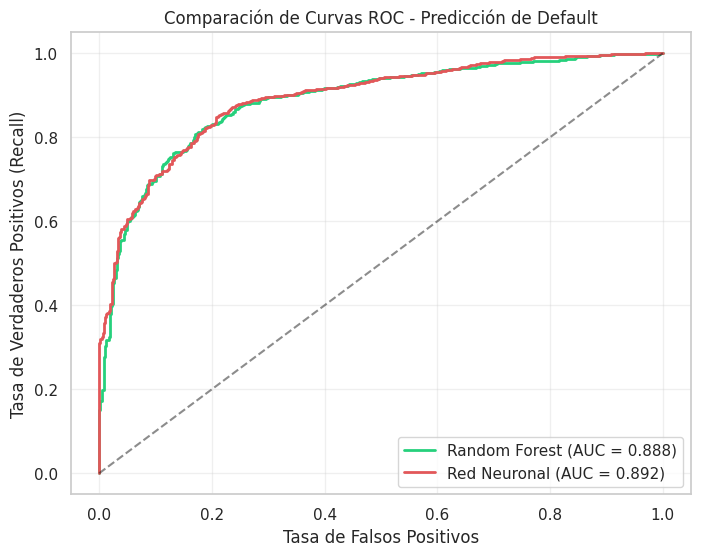

In [14]:
# ------------------------------------------------------------------------------
# grafica curva roc comparativa
# ------------------------------------------------------------------------------

# datos del arbol
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
# datos de la red neuronal
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_proba_nn)

plt.figure(figsize=(8, 6))

# ------------------------------------------------------------------------------
# curva de random forest
plt.plot(
    fpr_rf, 
    tpr_rf, 
    label=f'Random Forest (AUC = {auc_rf:.3f})', 
    color=_color_tecmi_light, 
    linewidth=2)

# ------------------------------------------------------------------------------
# curva de red neuronal
plt.plot(
    fpr_nn, 
    tpr_nn, 
    label=f'Red Neuronal (AUC = {auc_nn:.3f})', 
    color=_Red_, 
    linewidth=2)

# linea de ref
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)

# ------------------------------------------------------------------------------
# layout y leyendas
plt.title('Comparación de Curvas ROC - Predicción de Default')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

## 🎏 Análisis de diferencias en los modelos

De acuerdo con las pruebas y entrenamientos realizados se puede destacar que el modelo **Random Forest** utiliza menos recursos y menos tiempo para terminar sus tareas, mostrando un desempeño igual o superior al de la Red Neuronal Simple, lo que comprueba que este modelo se puede adecuar mejor a nuestro al dataset tabular.

También se puede destacar que el modelo Random Forest tiene una ventaja nativa con el dataset tabular entendiendo mejor las características de este, lo que le permite lidiar de mejor manera con los valores atípicos y administrar el desbalance presentado en el caso de Novacredit en la variable objetivo. 
En cambio, en la Red Neuronal, al implementarse en una sola capa, actúa como una Regresión Logística mejorada pero le cuesta capturar más detalles sin una arquitectura más elaborada.

Dadas las pruebas realizadas se concluye que la Red Neuronal genera predicciones exactas, pero funciona como una caja negra de información pues sufre de poca explicabilidad para poder entender que variables motivan el rechazo o aprobación de un cliente. Por otra parte, el Random Forest, proporciona un análisis directo de variables importantes, permitiendo al equipo de negocio en NovaCredit redactar políticas exactas de acuerdo al tipo o grupo de clientes.

### 🎖️ Decisión final

Se selecciona el modelo **🌳 Random Forest** como el modelo definitivo en este caso de Novacredit para pasar a la fase de producción, priorizando el balance entre **precisión predictiva** y **explicabilidad**.

# 🧪 Integración de prácticas básicas de MLOps con MLflow

En este bloque se emplea MLflow para integrar un sistema de gestión de experimentos, permitiendo auditar por qué un modelo es mejor que otro y guardar versiones exactas de los resultados.

La herramienta MLflow actuará como la bitácora de versiones del modelo registrando algunos elementos como:

- Parámetros y configuración.
- Métricas del resultado.
- Artefactos generados por el modelo entrenado y gráficas.

A continuación se realiza la integración del modelo elegido en el paso anterior, el Random Forest, bajo el control de MLflow.

## 👾 Configuración del experimento y parametros

A continuación se define un arreglo de parametros para implementar una búsqueda de mejores parametros y registrar cada iteración con MLflow, esto permitirá comparar y seleccionar la mejor versión del modelo con evidencia y resultados.

In [15]:
# ------------------------------------------------------------------------------
# Configuración del experimento y parametros
# ------------------------------------------------------------------------------
_EXP_NAME_ = 'NovaCredit_Risk_Default_Iterativo'
_EXP_SAVE_NAME_ = 'model_rf_empaquetado'
_MODEL_NOVA_ = 'RandomForestClassifier'


# init del experimento en MLflow
mlflow.set_experiment(_EXP_NAME_)

# ------------------------------------------------------------------------------
# arreglo de parametros
params_grid = [
    {"n_estimators": 50,  "max_depth": 5,    "class_weight": "balanced"},
    {"n_estimators": 100, "max_depth": 5,    "class_weight": "balanced"},
    {"n_estimators": 100, "max_depth": 10,   "class_weight": "balanced"},
    {"n_estimators": 200, "max_depth": 10,   "class_weight": "balanced"},
    {"n_estimators": 200, "max_depth": None, "class_weight": "balanced"},
    {"n_estimators": 300, "max_depth": 15, "class_weight": "balanced"},
    {"n_estimators": 300, "max_depth": None, "class_weight": "balanced"},
]

# ------------------------------------------------------------------------------
display_mensaje("🤖 Configuración del experimento exitosa")
print(f"Arreglo de parametros: {len(params_grid)}")

# limpieza de logs y advertencias
warnings.filterwarnings("ignore", module="mlflow")
warnings.filterwarnings("ignore", message=".*Saving scikit-learn models.*")
# limpieza de logs internos de MLflow
logging.getLogger("mlflow").setLevel(logging.ERROR)

2026/04/14 16:15:17 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/14 16:15:17 INFO mlflow.store.db.utils: Updating database tables
2026/04/14 16:15:18 INFO mlflow.tracking.fluent: Experiment with name 'NovaCredit_Risk_Default_Iterativo' does not exist. Creating a new experiment.



 --- 🤖 Configuración del experimento exitosa --- 
Arreglo de parametros: 7


## 🔬 Integración de MLOps

In [16]:
# ------------------------------------------------------------------------------
# 🔬 Integración de MLOps
# ------------------------------------------------------------------------------
display_mensaje(f"🔬 Iniciando iteración de {len(params_grid)} experimentos en MLflow")

# iteranto en el arreglo de parametros con enumerate
for i, params in enumerate(params_grid, 1):
    
    # control de variables
    depth_str = params['max_depth'] if params['max_depth'] is not None else "SIN_LIMITE"
    # nombre de version concatenado con parametros
    run_name = f"RF_v{i}_Est{params['n_estimators']}_Depth{depth_str}"
    
    # ------------------------------------------------------------------------------
    with mlflow.start_run(run_name=run_name):
        
        # registrando el nombre del algoritmo
        mlflow.log_param("algoritmo", _MODEL_NOVA_)
        # registrando los parametros directamente desde el arreglo iterado
        mlflow.log_params(params)
        
        # inicio de entrenamiento
        display_mensaje(f"🤖 Entrenando versión {i}/{len(params_grid)}: {run_name}")
        
        # ------------------------------------------------------------------------------
        rf_model = RandomForestClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            class_weight=params["class_weight"],
            random_state=42,
            n_jobs=-1 # config para uso de todos los procesadores para mayor velocidad
        )
        # train
        rf_model.fit(X_train_prep, y_train)

        # iniciando evaluacion
        y_proba = rf_model.predict_proba(X_test_prep)[:, 1]
        y_pred = rf_model.predict(X_test_prep)
        
        # ------------------------------------------------------------------------------
        auc = roc_auc_score(y_test, y_proba),
        acc = accuracy_score(y_test, y_pred),
        prec = precision_score(y_test, y_pred),
        rec = recall_score(y_test, y_pred)
        #-----------------------------------------
        metrics = {
            "roc_auc": roc_auc_score(y_test, y_proba),
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred)
        }
        
        # ------------------------------------------------------------------------------
        # registrando metricas y artefactos
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(rf_model, _EXP_SAVE_NAME_)

    # ------------------------------------------------------------------------------
    # resultados de ejecución
    print(f"🧪 Experimento {run_name} finalizado")
    print(f"Parametros evaluados | n_estimators={params['n_estimators']} | max_depth={params['max_depth']}")
    print(f"↳ Métricas registradas:")
    rounded_dict = {k: round(v, 4) for k, v in metrics.items()}
    print(rounded_dict) 
    print('-' * 80)

# ------------------------------------------------------------------------------
display_mensaje("✅ Conjunto de experimentos completados")


 --- 🔬 Iniciando iteración de 7 experimentos en MLflow --- 

 --- 🤖 Entrenando versión 1/7: RF_v1_Est50_Depth5 --- 
🧪 Experimento RF_v1_Est50_Depth5 finalizado
Parametros evaluados | n_estimators=50 | max_depth=5
↳ Métricas registradas:
{'roc_auc': 0.8792, 'accuracy': 0.8385, 'precision': 0.9129, 'recall': 0.8701}
--------------------------------------------------------------------------------

 --- 🤖 Entrenando versión 2/7: RF_v2_Est100_Depth5 --- 
🧪 Experimento RF_v2_Est100_Depth5 finalizado
Parametros evaluados | n_estimators=100 | max_depth=5
↳ Métricas registradas:
{'roc_auc': 0.8807, 'accuracy': 0.8375, 'precision': 0.9122, 'recall': 0.8695}
--------------------------------------------------------------------------------

 --- 🤖 Entrenando versión 3/7: RF_v3_Est100_Depth10 --- 
🧪 Experimento RF_v3_Est100_Depth10 finalizado
Parametros evaluados | n_estimators=100 | max_depth=10
↳ Métricas registradas:
{'roc_auc': 0.887, 'accuracy': 0.843, 'precision': 0.9128, 'recall': 0.8767}
--

## 🔍 Evaluando experimento

In [17]:
# ------------------------------------------------------------------------------
# 🔍 Evaluando experimento
# ------------------------------------------------------------------------------

# obteniendo ID del experimento
exp = mlflow.get_experiment_by_name(_EXP_NAME_)

# buscando las ejecuciones del experimento
df_runs = mlflow.search_runs(experiment_ids=[exp.experiment_id])

# filtrando columnas para reporte limpio
df_summary = df_runs[[
    "run_id", 
    "tags.mlflow.runName",
    "params.n_estimators", 
    "params.max_depth", 
    "metrics.roc_auc",
    "metrics.recall",
    "metrics.precision",
    "metrics.accuracy"
]].copy()

# ------------------------------------------------------------------------------
# ordenando por AUC mas fuerte
df_summary = df_summary.sort_values("metrics.roc_auc", ascending=False).reset_index(drop=True)

display_mensaje("🏆 Mejores Modelos Evaluados")
# aplicando mapa de calor en valores altos
df_summary.head(10).style.background_gradient(
    subset=['metrics.roc_auc', 'metrics.recall'], 
    cmap='Greens'
    )


 --- 🏆 Mejores Modelos Evaluados --- 


,run_id,tags.mlflow.runName,params.n_estimators,params.max_depth,metrics.roc_auc,metrics.recall,metrics.precision,metrics.accuracy
0,39393c7d3f86474490292876818cf1e3,RF_v4_Est200_Depth10,200,10,0.887815,0.879367,0.911825,0.844000
1,b1c16f262df64776af13f476ba623ee3,RF_v3_Est100_Depth10,100,10,0.886995,0.876730,0.912835,0.843000
2,a5c4560a0e6541c2b5f24bf4d504d58d,RF_v7_Est300_DepthSIN_LIMITE,300,None,0.886520,0.937376,0.859734,0.836500
3,c651c0614fa2451894eec2061e8d61af,RF_v6_Est300_Depth15,300,15,0.885936,0.909031,0.881150,0.838000
4,99545cd0a1a14bd7924de6ee6630ab46,RF_v5_Est200_DepthSIN_LIMITE,200,None,0.885596,0.935399,0.860522,0.836000
5,a1440ed31c3a419795c04decfe9185ee,RF_v2_Est100_Depth5,100,5,0.880699,0.869479,0.912172,0.837500
6,0f8241fdb887457682b6673d37d9d0b0,RF_v1_Est50_Depth5,50,5,0.879224,0.870138,0.912863,0.838500


## 🥇 Mejor versión del modelo

In [18]:
# ------------------------------------------------------------------------------
# 🥇 Mejor versión del modelo
# ------------------------------------------------------------------------------
# Extraemos el ID de la mejor ejecución (la fila 0 tras ordenar)
best_run = df_summary.iloc[0]
best_run_id = df_summary.loc[0, 'run_id']
best_run_name = df_summary.loc[0, 'tags.mlflow.runName']
best_auc = df_summary.loc[0, 'metrics.roc_auc']

display_mensaje("🥇 Cargando la mejor versión del modelo")
print(f"Modelo: {best_run_name} (AUC: {best_auc:.4f})")

display(best_run)


 --- 🥇 Cargando la mejor versión del modelo --- 
Modelo: RF_v4_Est200_Depth10 (AUC: 0.8878)


run_id                 39393c7d3f86474490292876818cf1e3
tags.mlflow.runName                RF_v4_Est200_Depth10
params.n_estimators                                 200
params.max_depth                                     10
metrics.roc_auc                                0.887815
metrics.recall                                 0.879367
metrics.precision                              0.911825
metrics.accuracy                                  0.844
Name: 0, dtype: object

# 🩺 Evaluación e interpretación de los resultados del modelo

En este bloque se evaluarán las métricas obtenidas en el pipeline de MLflow para ofrecer una explicación de los resultados, detallar las ventajas del modelo y ser transparentes sobre dónde pueden ocurrir fallas.

## 📖 Métricas obtenidas

| Item                       | Valor                        |
| ------------------------ | ------------------------------ |
| Modelo                    | RF_v4_Est200_Depth10  |
| n_estimators             | 200                            |
| max_depth                 | 10                     |
| roc_auc                     | 0.887815                        |
| recall                    | 0.879367                        |
| precision                  | 0.911825                       |
| accuracy                  | 0.844                       |

### 📃 Interpretación de las métricas obtenidas

La evaluación del modelo **Random Forest Optimizado** elegido para el escenario de NovaCredit arrojó métricas clave para el beneficio de la salud financiera del negocio. En este escenario se eligió a la métrica de el **Área Bajo la Curva** como la métrica principal de selección, dicho esto, el algoritmo arrojo un valor de AUC elevado, de 0.888, muy cercano a 0.90, lo que confirma que el modelo es bastante capaz de identificar y separar a un cliente con alta probabilidad de morosidad de uno que pagará a tiempo. 

En cuanto a la métrica de **Recall**, con un 0.88, se garantizó en maximizar el *Recall* configurando adecuadamente el *peso balanceado de clases *en los *parametros* del *RandomForestClassifier*, este ajuste técnico ayuda a que el modelo pueda identificar *positivamente* a la gran mayoría de los clientes morosos.


Por otro lado, la métrica **Precision**, con un 0.911, muy alta, esta asegurando que el modelo tiene una alta precisión, y podemos estar seguros de que cuando el sistema identifica a un cliente como "Riesgo de Default", el equipo de cobranzas de la empresa puede actuar con la confianza de que no están molestando injustificadamente a un cliente leal o sin historial de morosidad.

## 💪 Evaluando la mejor versión del modelo

In [19]:
# ------------------------------------------------------------------------------
# Evaluando la mejor versión del modelo
# ------------------------------------------------------------------------------

# cargando modelo empaquetado desde MLflow
model_uri = f"runs:/{best_run_id}/{_EXP_SAVE_NAME_}"
best_model = mlflow.sklearn.load_model(model_uri)
_NO_CLIENTES_EVALUAR_ = 10

# ------------------------------------------------------------------------------
# 🤖 ejecutnado simulacion | 
#   obteniendo pedicciones sobre los primeros 10 clientes de prueba
# ------------------------------------------------------------------------------
display_mensaje("🤖 Ejecutando una simulación de predicciones")

# evaluando predicciones para los primeros clientes
predicciones_muestra = best_model.predict(X_test_prep[:_NO_CLIENTES_EVALUAR_])
probabilidades_muestra = best_model.predict_proba(X_test_prep[:_NO_CLIENTES_EVALUAR_])[:, 1]
print(f"⚙️ Evaluando modelo {best_run_name} ...")

# resultados de ejecución
print("-" * 80)
print(f"🔍 Predicciones para los primeros {_NO_CLIENTES_EVALUAR_} clientes de prueba")
print("-" * 80)

for idx, (pred, proba) in enumerate(zip(predicciones_muestra, probabilidades_muestra)):
    # mostrando los resultados de la prediccion
    estado = "Default" if pred == 1 else "Al Corriente"
    estado_icono = "❌" if pred == 1 else "✅"
    print(f"{estado_icono} Cliente {idx+1}: {estado} (Probabilidad de riesgo: {proba:.1%})")


 --- 🤖 Ejecutando una simulación de predicciones --- 
⚙️ Evaluando modelo RF_v4_Est200_Depth10 ...
--------------------------------------------------------------------------------
🔍 Predicciones para los primeros 10 clientes de prueba
--------------------------------------------------------------------------------
❌ Cliente 1: Default (Probabilidad de riesgo: 50.1%)
❌ Cliente 2: Default (Probabilidad de riesgo: 84.0%)
❌ Cliente 3: Default (Probabilidad de riesgo: 69.8%)
✅ Cliente 4: Al Corriente (Probabilidad de riesgo: 29.5%)
❌ Cliente 5: Default (Probabilidad de riesgo: 58.5%)
❌ Cliente 6: Default (Probabilidad de riesgo: 90.8%)
✅ Cliente 7: Al Corriente (Probabilidad de riesgo: 27.6%)
❌ Cliente 8: Default (Probabilidad de riesgo: 95.4%)
❌ Cliente 9: Default (Probabilidad de riesgo: 88.3%)
✅ Cliente 10: Al Corriente (Probabilidad de riesgo: 25.8%)


### 📊 Distribución de variable objetivo default_12m

Con la simulación de predicciones ejecutada anteriormente podemos comprobar como el modelo detecta oportunamente el >70% de Riesgo Default que existe en la cartera de clientes. 


 --- Distribución de variable default_12m --- 
Porcentaje de distribución:
default_12m
1    75.84
0    24.16
Name: proportion, dtype: float64


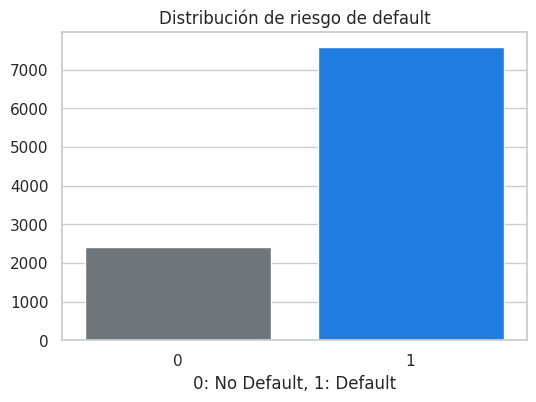

In [20]:
# ------------------------------------------------------------------------------
# Distribución de variable objetivo default_12m
# ------------------------------------------------------------------------------
display_mensaje("Distribución de variable default_12m")
print("Porcentaje de distribución:")
dist_default = df_final_preparado['default_12m'].value_counts(normalize=True) * 100
print(dist_default)

plt.figure(figsize=(6, 4))
ax = sns.countplot(
    data=df_final_preparado, 
    x='default_12m', 
    palette=[_color_gray, _color_primary])

plt.title('Distribución de riesgo de default')
plt.xlabel('0: No Default, 1: Default')
plt.ylabel('')
plt.show()

## 🔍 Detección de combinaciones de alto riesgo

Dentro de la cartera de clientes podrían existir algunos clientes que están dentro de los parámetros normales, pero que combinan ciertos factores que los vuelven tóxicos para la empresa, en esta sección se intentará detectar a estos casos particulares.


 --- Buscando combinaciones de comportamiento... --- 

 --- Patrones de comportamiento combinado --- 
Analizando: Mora Alta cruzada con Utilización Alta



,Mora_Alta,Utilizacion_Alta,Total_Casos,Tasa_Default
0,False,False,7287,72.700000
1,False,True,1512,72.000000
2,True,False,997,99.500000
3,True,True,204,99.500000


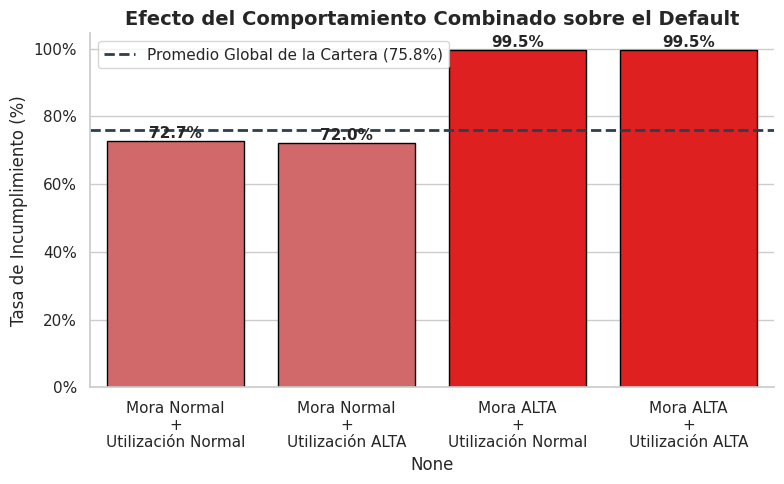

In [21]:
# ------------------------------------------------------------------------------
# Detección de combinaciones de alto riesgo
# ------------------------------------------------------------------------------
display_mensaje("Buscando combinaciones de comportamiento...")

df_prep  = df_final_preparado.copy()

# definiendo flags de comportamiento extremo 
df_prep['Mora_Alta'] = df_prep['pagos_atrasados_12m'] > 1.0
df_prep['Utilizacion_Alta'] = df_prep['porcentaje_utilizacion'] > 1.0
df_prep['Ingreso_Bajo'] = df_prep['ingreso_mensual'] < -0.5

# agrupando clientes por combinaciones extremas
patrones_riesgo = df_prep.groupby(['Mora_Alta', 'Utilizacion_Alta'])['default_12m'].agg(
    Total_Casos='count',
    Tasa_Default='mean'
).reset_index()

# porcentajes
patrones_riesgo['Tasa_Default'] = (patrones_riesgo['Tasa_Default'] * 100).round(1)

# ordenando de mayor a menor
#patrones_riesgo = patrones_riesgo.sort_values('Tasa_Default', ascending=False)

display_mensaje("Patrones de comportamiento combinado")
print("Analizando: Mora Alta cruzada con Utilización Alta\n")
display(patrones_riesgo.style.background_gradient(subset=['Tasa_Default'], cmap='Reds'))

# ------------------------------------------------------------------------------
# Visualización del efecto combinado
# ------------------------------------------------------------------------------
import matplotlib.ticker as mtick

# promedio global para la línea de referencia
promedio_global = df_prep['default_12m'].mean() * 100

# gráfico de barras y asignacion de colores en base al %
colores = [_Red_ if tasa < promedio_global else _color_danger for tasa in patrones_riesgo['Tasa_Default']]

plt.figure(figsize=(8, 5))
# barplot
ax = sns.barplot(
    data=patrones_riesgo, 
    x=patrones_riesgo.index, 
    y='Tasa_Default', 
    palette=colores,
    edgecolor='black'
)

# etiquetas
etiquetas_x = []
for i, row in patrones_riesgo.iterrows():
    mora = "Mora ALTA" if row['Mora_Alta'] else "Mora Normal"
    util = "Utilización ALTA" if row['Utilizacion_Alta'] else "Utilización Normal"
    etiquetas_x.append(f"{mora}\n+\n{util}")

ax.set_xticklabels(etiquetas_x)

# titulos
plt.title("Efecto del Comportamiento Combinado sobre el Default", fontsize=14, fontweight='bold')
plt.ylabel("Tasa de Incumplimiento (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# etiquetas en las barras
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')


# línea de promedio global
plt.axhline(y=promedio_global, color='#2c3e50', linestyle='--', linewidth=2, 
            label=f'Promedio Global de la Cartera ({promedio_global:.1f}%)')

# sin bordes
sns.despine()
plt.legend(loc='upper left')

# show
plt.tight_layout()
#plt.savefig("figs/11-comportamiento-combinado.png")
plt.show()


## 🪧 Limitaciones del pipeline

Desde una perspectiva técnica y de acuerdo con lo aprendido durante los últimos cursos en TecMilenio, el pipeline presentado en este Notebook podría presentar algunas limitaciones tales como:

1. La lógica del modelo actual se encarga de evaluar los saldos registrados en los últimos 12 meses de un cliente, lo que provoca que se vea al registro del cliente desde una visión estática, sin lograr entender a detalle las fluctuaciones que se vivieron mes a mes. Esto puede limitar la capacidad de ver y entender como un cliente va mejorando o empeorando financieramente mes a mes.

2. Durante el entrenamiento del *Random Forest*, se definió un objeto de tipo *ColumnTransformer*, donde se define el grupo de transformaciones, imputaciones y escalamientos del conjunto de datos según las reglas dictadas en el mismo ColumnTransformer. Una de ellas fue la de imputar los valores nulos numéricos con la mediana global, lo cual puede resultado viable para esta practica, pero en el mundo real este tipo de imputaciones debería de estar mas en relación con las reglas de negocio y características del cliente mismo.

3. Finalmente, y como dato macroeconómico, el modelo solo tiene capacidad de percepción "local", lo que significa que se asume que el comportamiento financiero será siempre constante, no se toman en cuenta temas de inflación, devaluación, patrones de gasto, y demás variables macroeconomicas que seguramente tendrían un impacto profundo y directo en el comportamiento de la cartera de clientes.

# 📃 Conclusión

Anteriormente, la empresa NovaCredit Solutions mantenía un enfoque reactivo sobre el Riesgo Default basado en observar la morosidad pasada de su cartera de clientes, pero gracias a la implementación de este Pipeline ahora la empresa puede presumir de un enfoque más proactivo y personalizado, impulsado por algoritmos matemáticos y automatización.

Al integrar el modelo supervisado **Random Forest** en un ciclo de vida MLOps, la empresa ahora cuenta con la capacidad de detectar oportunamente al 88.8% de los clientes propensos a no pagar, permitiendo congelar líneas de crédito antes de que ocurra la pérdida de capital. Este bloqueo automático de clientes puede estar sustentado con toda la confianza en el algoritmo que detecta a los clientes que muestren una combinación alarmante de resultados de Mora Alta y Utilización Alta, los cuales debemos recordar que mantienen un un 99.5% de probabilidad de default, automatizando así tareas criticas para el negocio.

Dentro del pipeline, y en base a los análisis realizados en las actividades pasadas se ha podido gestionar una personalización estratégica en el modelo, brindándole la capacidad de diferenciar entre el 5% de los clientes con actividades de carácter anómalas, como lo son los VIP Volátiles, contra los segmentos con conductas más normales, como lo son los grupos de clientes Leales Estabilizados. De esta manera se facilita la identificación de segmentos para la viable gestión de estrategias de marketing y gestión de riesgo de manera personalizada para cada grupo.

## 🪶 Reflexión Final

La implementación de este pipeline puede ayudar a procesar miles de historiales crediticios y frenar el problema financiero al cual se esta enfrentando el negocio, sin embargo, depender a ciegas del algoritmo podría inducir a correr ciertos riesgos éticos y operativos. Por ejemplo, si el modelo rechaza automáticamente perfiles basándose únicamente en características geográficas o de edad, la empresa podría incurrir en prácticas de discriminación al momento de evaluar la asignación del crédito. Por lo tanto, es altamente recomendable implementar el modelo bajo un esquema de supervisión humana para los casos extremos. 
Esto quiere decir que el modelo debe automatizar el 80% de las decisiones sumamente claras, como lo son casos de aprobaciones financieramente seguras o rechazos definitivamente contundentes, enviando el 20% de los casos que podrían ser dudosos a un comité de revisión humana para su veredicto final. Esta delegación de tareas se podría implementar en el mismo pipeline para cuando se detecten los casos altamente extremos o raros enviarlos al siguiente proceso. 

De esta manera se estaría abordando el caso de NovaCredit desde un enfoque automatizado sin perder el análisis ético y humano.

*Este análisis esta sustentado en el algoritmo *IsolationForest* implementado en la Actividad 2, durante el cual se identificaron los valores atípicos mediante la aplicación del algoritmo en los espacios multidimensionales.*

# 📺 Panel de exploración de predicciones

A continuación se integra un panel explorador de predicciones, integrando el dataframe original de entrenamiento con las predicciones del modelo Random Forest y la segmentación guiada de K-Means. El panel tiene la intención de mostrar de manera visual el poder de las predicciones del algoritmo y su efectividad.

In [22]:
# ------------------------------------------------------------------------------
# 📺 Panel de exploración
# ------------------------------------------------------------------------------

display_mensaje("🔨 Construyendo el Panel Explorador")

print("🔨 Construyendo el DataFrame de analisis...")
# armando el dataframe del panel con el conjunto de prueba
# se utiliza el dataframe original para tener los tooltips correctos en la grafica
df_panel_final = X_test.copy()

# asegurando tener la colummna id_cliente
if 'id_cliente' not in df_panel_final.columns:
    df_panel_final['id_cliente'] = [f"C-TEST-{i}" for i in range(len(df_panel_final))]

# ------------------------------------------------------------------------------
# integrando el nuevo dataframe con las predicciones del modelo random forest
print("🔨 Integrando predicciones al dataframe...")
df_panel_final['default_proba'] = best_model.predict_proba(X_test_prep)[:, 1]
df_panel_final['prediccion_default'] = best_model.predict(X_test_prep)

# ------------------------------------------------------------------------------
# reduciendo las dimenciones del PCA a 2 componentes para poder graficarlas
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_test_prep)

df_panel_final['PCA_C1'] = pca_result[:, 0]
df_panel_final['PCA_C2'] = pca_result[:, 1]


# ------------------------------------------------------------------------------
# Aplicando K-Means
# ------------------------------------------------------------------------------
# simulando los 4 segmentos principales definimos en la Actividad 2 con kmeans
k_optimo = 4
print(f"☘️ Aplicando K-Means...")

kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_panel_final['cluster_id'] = kmeans.fit_predict(X_test_prep)

# etiquetas finales al DataFrame
df_panel_final["cluster_final"] = kmeans.labels_

centroides_pca = pca.transform(kmeans.cluster_centers_)

# asginación de nombres a cada cluster
# se mapean los numeros a nombres descriptivos para facilitar la lectura
nombres_estrategicos = {
    0: 'Leales Estabilizados',
    1: 'Inactivos Bajo Límite',
    2: 'VIP Volátiles',
    3: 'Apalancados Crónicos'
}

df_panel_final['Segmento'] = df_panel_final['cluster_id'].map(nombres_estrategicos)

print("✔️ K-Means finalizado.")


# ------------------------------------------------------------------------------
# detectando anomalias - descartando el 5% de la cartera con comportamiento extremo
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df_panel_final['Outlier_Flag'] = iso_forest.fit_predict(X_test_prep)
df_panel_final['Es_Anomalia'] = df_panel_final['Outlier_Flag'].map({1: 'Normal', -1: 'Atípico'})

print("✅ Panel explorador terminado.")
#print(f"Dimensiones: {df_panel_final.shape}")
#display(df_panel_final.head())

# ------------------------------------------------------------------------------
# panel iteractivo con ploty
# estableciendo el limite de credito para el limite de burbuja
col_tamaño = 'limite_credito' if 'limite_credito' in df_panel_final.columns else 'ingreso_mensual'

# scatter de PCA's
fig = px.scatter(
    df_panel_final, 
    x='PCA_C1', 
    y='PCA_C2',
    color='Segmento',
    size=col_tamaño,
    symbol='Es_Anomalia', # mostrando la diferencia entre anomalias y normales
    hover_data=['id_cliente', 'ingreso_mensual', 'default_proba', 'prediccion_default'],
    title="Panel explorador de predicciones - NovaCredit",
    color_discrete_sequence=px.colors.qualitative.Pastel,
    opacity=0.8
)

fig.update_layout(
    xaxis_title="Comportamiento financiero base", # Componente 1
    yaxis_title="Varianza de riesgo", # Componente 2
    legend_title="Segmentos y anomalías",
    template="plotly_white",
    height=700
)

fig.show()


 --- 🔨 Construyendo el Panel Explorador --- 
🔨 Construyendo el DataFrame de analisis...
🔨 Integrando predicciones al dataframe...
☘️ Aplicando K-Means...
✔️ K-Means finalizado.
✅ Panel explorador terminado.
